# 401 — Análisis empírico de leakage por genotipo (Corrección #20 del jurado)

**Objetivo:** verificar empíricamente la hipótesis del jurado de que el CNN-2D aprendió la estructura espacial de las parcelas (polígonos etiquetados manualmente) en lugar de la huella espectral del estrés. Se analiza la variable `entry` (genotipo) y su distribución en el split espacial, y se evalúa el rendimiento del modelo por genotipo.

**Restricciones:**
- Sin reentrenamiento. Solo inferencia con pesos finales ya entrenados.
- Los resultados experimentales reportados en la tesis están bloqueados.

**Archivos usados:**
- `data/raw/labels_export.gpkg` — metadata de parcelas (entry, class, plot, rep, binary)
- `data/processed/splits/by_plot_assign_binary.csv` — asignación de plots a splits
- `data/processed/splits/by_plot_split_id_binary.tif` — máscara espacial de splits
- `models/cnn2d_final_model_weights.pt` + `models/cnn2d_final_model_info.json`
- `models/robust_scaler.pkl`


# Librerías

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [2]:
import os
import json
import joblib
import warnings
import time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.features import rasterize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score
)

from spectralcrop.utils.path_manager import PathManager

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

PM = PathManager()

def _resolve(path):
    if isinstance(path, list):
        return [p for p in path if 'spectralcrop' not in p][0]
    return path

RAW_PATH       = _resolve(PM.get_abs_path_folder('raw'))
PROCESSED_PATH = _resolve(PM.get_abs_path_folder('processed'))
INTERIM_PATH   = _resolve(PM.get_abs_path_folder('interim'))
MODELS_PATH    = _resolve(PM.get_abs_path_folder('models'))
REPORTS_PATH   = _resolve(PM.get_abs_path_folder('reports'))

FIGURES_DIR = os.path.join(REPORTS_PATH, 'figures', 'category_D')
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device={device}')
print(f'INTERIM_PATH={INTERIM_PATH}')
print(f'PROCESSED_PATH={PROCESSED_PATH}')
print(f'FIGURES_DIR={FIGURES_DIR}')

device=cuda
INTERIM_PATH=c:\Users\mario\Documentos\personal_projects\thesis\data\interim\
PROCESSED_PATH=c:\Users\mario\Documentos\personal_projects\thesis\data\processed\
FIGURES_DIR=c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\category_D


In [3]:
# Mapeo oficial entry -> genotipo (Tabla 8, Anexo 32)
GENOTYPE_MAP = {
    1: 'L1-12702',
    2: 'L2-G11819',
    3: 'L3-G50834',
    4: 'L4-50840',
    5: 'L15-51433',
    6: 'L17-G51018',
    7: 'Liborino',
    8: 'Cargamanto',
    9: 'entry_9_no_documentado',
    10: 'entry_10_no_documentado',
}
OFFICIAL_ENTRIES    = list(range(1, 9))
UNDOCUMENTED_ENTRIES = [9, 10]

## 1. Exploración general del GeoPackage

In [4]:
GPKG_PATH = os.path.join(RAW_PATH, 'labels_export.gpkg')
gdf = gpd.read_file(GPKG_PATH, layer='labels2')
df  = gdf.drop(columns='geometry')

print(f'n_filas: {len(df)}')
print(f'n_plots unicos: {df["plot"].nunique()}')
print(f'n_entries unicos: {df["entry"].nunique()}')
print(f'reps: {sorted(df["rep"].unique().tolist())}')
print()
for col in ['binary', 'class', 'entry', 'rep']:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

n_filas: 335
n_plots unicos: 24
n_entries unicos: 10
reps: [1, 2, 3]

  binary: [0, 1]
  class: [0, 1, 2, 3]
  entry: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  rep: [1, 2, 3]


In [5]:
# Verificacion: binary debe ser equivalente a (class >= 1)
check = df.copy()
check['binary_derived'] = (check['class'] >= 1).astype(int)
mismatch = check[check['binary'] != check['binary_derived']]
print(f'Filas con binary != (class >= 1): {len(mismatch)}')
print('OK: binary es consistente con class' if len(mismatch) == 0 else mismatch)

Filas con binary != (class >= 1): 0
OK: binary es consistente con class


## 2. EDA del campo `entry` — identificación de entries no documentados

In [6]:
vc_df = (df['entry'].value_counts()
           .sort_index()
           .reset_index()
           .rename(columns={'entry': 'entry', 'count': 'n_registros'}))
vc_df.columns = ['entry', 'n_registros']
vc_df['genotipo']    = vc_df['entry'].map(GENOTYPE_MAP)
vc_df['documentado'] = vc_df['entry'].apply(lambda x: 'Si' if x <= 8 else 'NO')
print(vc_df.to_string(index=False))

print()
undoc = df[df['entry'] > 8]
print(f'Entries no documentados: {sorted(undoc["entry"].unique().tolist())}')
print(f'n_registros con entry > 8: {len(undoc)} ({len(undoc)/len(df)*100:.1f}% del total)')

 entry  n_registros                genotipo documentado
     1           37                L1-12702          Si
     2           35               L2-G11819          Si
     3           37               L3-G50834          Si
     4           41                L4-50840          Si
     5           45               L15-51433          Si
     6           41              L17-G51018          Si
     7           37                Liborino          Si
     8           40              Cargamanto          Si
     9           11  entry_9_no_documentado          NO
    10           11 entry_10_no_documentado          NO

Entries no documentados: [9, 10]
n_registros con entry > 8: 22 (6.6% del total)


In [7]:
# Tabla cruzada entry x class
ct = pd.crosstab(df['entry'], df['class'], margins=True)
ct.index = [
    f'{i} ({GENOTYPE_MAP.get(i, "?")})'  if i != 'All' else 'TOTAL'
    for i in ct.index
]
ct.columns = [f'class={c}' if c != 'All' else 'TOTAL' for c in ct.columns]
print('Tabla cruzada: entry x class (n registros)')
print(ct.to_string())

Tabla cruzada: entry x class (n registros)
                              class=0  class=1  class=2  class=3  TOTAL
1 (L1-12702)                        9        9       10        9     37
2 (L2-G11819)                       8        9        9        9     35
3 (L3-G50834)                       8        9       10       10     37
4 (L4-50840)                        6       14        9       12     41
5 (L15-51433)                       7       10       13       15     45
6 (L17-G51018)                      6       10       12       13     41
7 (Liborino)                        6       11       10       10     37
8 (Cargamanto)                      9       12        9       10     40
9 (entry_9_no_documentado)         11        0        0        0     11
10 (entry_10_no_documentado)       11        0        0        0     11
TOTAL                              81       84       82       88    335


In [8]:
# HALLAZGO CRITICO
print('Entries no documentados: en que clases aparecen?')
for e in UNDOCUMENTED_ENTRIES:
    classes = sorted(df[df['entry'] == e]['class'].unique().tolist())
    bins    = sorted(df[df['entry'] == e]['binary'].unique().tolist())
    print(f'  entry={e}: class={classes}, binary={bins}')

print()
# Impacto cuantitativo
total_reg   = len(df)
undoc_reg   = (df['entry'] > 8).sum()
class0_reg  = (df['class'] == 0).sum()
undoc_c0    = ((df['entry'] > 8) & (df['class'] == 0)).sum()

print('Impacto cuantitativo (registros):')
print(f'  Total: {total_reg}')
print(f'  Con entry no documentado: {undoc_reg} ({undoc_reg/total_reg*100:.1f}% del total)')
print(f'  class=0 (sano): {class0_reg}')
print(f'  class=0 con entry no documentado: {undoc_c0} ({undoc_c0/class0_reg*100:.1f}% de los sanos)')

print()
parcelas = df.drop_duplicates(subset=['plot', 'class', 'entry', 'rep'])
tot_p     = len(parcelas)
undoc_p   = (parcelas['entry'] > 8).sum()
c0_p      = (parcelas['class'] == 0).sum()
undoc_c0_p = ((parcelas['entry'] > 8) & (parcelas['class'] == 0)).sum()

print('Impacto cuantitativo (parcelas unicas):')
print(f'  Total parcelas: {tot_p}')
print(f'  Con entry no documentado: {undoc_p} ({undoc_p/tot_p*100:.1f}% del total)')
print(f'  Parcelas class=0: {c0_p}')
print(f'  Parcelas class=0 con entry no documentado: {undoc_c0_p} ({undoc_c0_p/c0_p*100:.1f}% de los sanos)')

Entries no documentados: en que clases aparecen?
  entry=9: class=[0], binary=[0]
  entry=10: class=[0], binary=[0]

Impacto cuantitativo (registros):
  Total: 335
  Con entry no documentado: 22 (6.6% del total)
  class=0 (sano): 81
  class=0 con entry no documentado: 22 (27.2% de los sanos)

Impacto cuantitativo (parcelas unicas):
  Total parcelas: 97
  Con entry no documentado: 6 (6.2% del total)
  Parcelas class=0: 24
  Parcelas class=0 con entry no documentado: 6 (25.0% de los sanos)


## 3. Diagnóstico del split espacial por genotipo

El split fue realizado por plot (surco) con estratificación por clase binaria (`stratify=binary`).
El genotipo (`entry`) **no fue considerado** en la asignación del split.
Resultado: train=28, val=10, test=10 grupos (plot × binary).

**Pregunta clave:** ¿los entries no documentados (9 y 10) están en train, val o test?

In [9]:
SPLIT_CSV = os.path.join(PROCESSED_PATH, 'splits', 'by_plot_assign_binary.csv')
split_df  = pd.read_csv(SPLIT_CSV)

merged = df.merge(split_df[['binary', 'plot', 'split']], on=['binary', 'plot'], how='left')
print(f'Registros sin match: {merged["split"].isna().sum()}')
print(f'Distribucion: {merged["split"].value_counts().to_dict()}')

Registros sin match: 0
Distribucion: {'train': 196, 'test': 73, 'val': 66}


In [10]:
# Tabla cruzada entry x split (registros)
ct_es = pd.crosstab(merged['entry'], merged['split'], margins=True)
ct_es.index = [
    f'{i} ({GENOTYPE_MAP.get(i, "?")})'  if i != 'All' else 'TOTAL'
    for i in ct_es.index
]
print('Tabla cruzada: entry x split (n registros)')
print(ct_es.to_string())

Tabla cruzada: entry x split (n registros)
split                         test  train  val  All
1 (L1-12702)                    12     18    7   37
2 (L2-G11819)                   14     15    6   35
3 (L3-G50834)                    9     24    4   37
4 (L4-50840)                     0     31   10   41
5 (L15-51433)                   16     17   12   45
6 (L17-G51018)                   5     25   11   41
7 (Liborino)                     8     23    6   37
8 (Cargamanto)                   9     25    6   40
9 (entry_9_no_documentado)       0     11    0   11
10 (entry_10_no_documentado)     0      7    4   11
TOTAL                           73    196   66  335


In [11]:
# Detalle: entries no documentados por split
undoc_m = merged[merged['entry'] > 8]
print('Entries no documentados (9, 10) — detalle por split:')
print(undoc_m[['entry', 'plot', 'rep', 'class', 'binary', 'split']]
      .drop_duplicates()
      .sort_values(['entry', 'plot'])
      .to_string(index=False))

print()
for e in UNDOCUMENTED_ENTRIES:
    splits = sorted(merged[merged['entry'] == e]['split'].unique().tolist())
    n_test = (merged[(merged['entry'] == e) & (merged['split'] == 'test')]).shape[0]
    print(f'  entry={e}: en splits={splits}, n_registros_test={n_test}')

Entries no documentados (9, 10) — detalle por split:
 entry  plot  rep  class  binary split
     9     2    1      0       0 train
     9    16    2      0       0 train
     9    22    3      0       0 train
    10     4    1      0       0 train
    10    17    3      0       0 train
    10    21    3      0       0   val

  entry=9: en splits=['train'], n_registros_test=0
  entry=10: en splits=['train', 'val'], n_registros_test=0


In [12]:
# Tabla cruzada entry x split (parcelas unicas)
parc_m = merged.drop_duplicates(subset=['plot', 'class', 'entry', 'rep'])
ct_parc = pd.crosstab(parc_m['entry'], parc_m['split'], margins=True)
ct_parc.index = [
    f'{i} ({GENOTYPE_MAP.get(i, "?")})'  if i != 'All' else 'TOTAL'
    for i in ct_parc.index
]
print('Tabla cruzada: entry x split (parcelas unicas)')
print(ct_parc.to_string())

print()
for s in ['train', 'val', 'test']:
    ents = sorted(parc_m[parc_m['split'] == s]['entry'].unique().tolist())
    print(f'{s}: entries {ents}')

Tabla cruzada: entry x split (parcelas unicas)
split                         test  train  val  All
1 (L1-12702)                     4      6    2   12
2 (L2-G11819)                    4      5    2   11
3 (L3-G50834)                    3      7    1   11
4 (L4-50840)                     0      8    3   11
5 (L15-51433)                    3      4    4   11
6 (L17-G51018)                   1      8    3   12
7 (Liborino)                     2      7    2   11
8 (Cargamanto)                   3      7    2   12
9 (entry_9_no_documentado)       0      3    0    3
10 (entry_10_no_documentado)     0      2    1    3
TOTAL                           20     57   20   97

train: entries [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
val: entries [1, 2, 3, 4, 5, 6, 7, 8, 10]
test: entries [1, 2, 3, 5, 6, 7, 8]


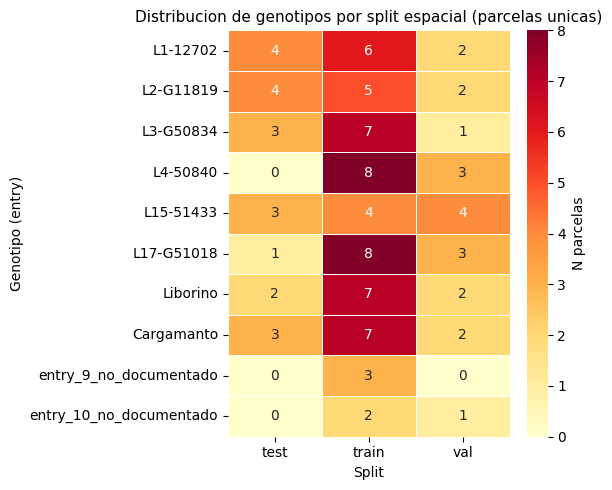

In [13]:
# Heatmap: entry x split (parcelas unicas)
ct_heat = pd.crosstab(parc_m['entry'], parc_m['split'])
ct_heat.index = [GENOTYPE_MAP.get(i, f'entry_{i}') for i in ct_heat.index]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ct_heat, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'N parcelas'})
ax.set_title('Distribucion de genotipos por split espacial (parcelas unicas)', fontsize=11)
ax.set_xlabel('Split')
ax.set_ylabel('Genotipo (entry)')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'heatmap_entry_split.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Inferencia CNN-2D por genotipo — test set

> **Nota:** Las celdas 4.1–4.4 cargan el cubo hiperspectral (~9.5 GB) y extraen los parches del test set. 
> Pueden tardar 15–30 min. Ejecutar solo cuando la sesión esté lista para el análisis completo.
>
> **Check de sanidad obligatorio:** PR-AUC global test debe coincidir con 0.9635 (± 0.001).

In [14]:
# 4.0 — Cargar modelo CNN-2D

class SpectralSpatialCNN2D(nn.Module):
    def __init__(self, n_channels=63, n_classes=2, dropout=0.3, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(n_channels, 32, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=pad)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.AdaptiveAvgPool2d((2, 2))
        self.fc1   = nn.Linear(128 * 2 * 2, 128)
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(128, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


with open(os.path.join(MODELS_PATH, 'cnn2d_final_model_info.json')) as f:
    model_info = json.load(f)

model2d = SpectralSpatialCNN2D(
    n_channels=model_info['n_channels'],
    dropout=model_info['dropout'],
    kernel_size=model_info['kernel_size'],
).to(device)
model2d.load_state_dict(
    torch.load(os.path.join(MODELS_PATH, 'cnn2d_final_model_weights.pt'),
               map_location=device, weights_only=False)
)
model2d.eval()

PATCH    = model_info['patch_size']
BEST_THR = model_info['best_thr']
print(f'Modelo listo: {sum(p.numel() for p in model2d.parameters()):,} params')
print(f'patch_size={PATCH}, best_thr={BEST_THR:.4f}')

Modelo listo: 372,994 params
patch_size=5, best_thr=0.3218


In [15]:
# 4.1 — Construir feature cube desde Zarr (63 canales) y cargar split raster
# Orden de canales: [NDVI, NDRE, CIgreen, PRI, PSRI, band_1, ..., band_374]
# Coincide con el orden usado durante el entrenamiento (notebook 305).
# Tiempo estimado: ~20 segundos (vs ~15 min con el BSQ).

t0 = time.time()

SPLIT_TIF = os.path.join(PROCESSED_PATH, 'splits', 'by_plot_split_id_binary.tif')

print('Cargando feature cube desde masked_reflectance.zarr...')
ds_zarr   = xr.open_zarr(os.path.join(INTERIM_PATH, 'masked_reflectance.zarr'))
bands_df  = pd.read_csv(os.path.join(INTERIM_PATH, 'bands_selected_by_segment.csv'))
sel_bands = bands_df['band_index'].tolist()

VI_NAMES = ['NDVI', 'NDRE', 'CIgreen', 'PRI', 'PSRI']
features_stack = xr.concat(
    [ds_zarr[VI_NAMES].to_array(dim='band'),
     ds_zarr['reflectance'].isel(band=sel_bands)],
    dim='band'
).transpose('y', 'x', 'band')

cube_raw = features_stack.values.astype(np.float32)
H, W, n_feat = cube_raw.shape
print(f'Feature cube: {cube_raw.shape}, elapsed: {time.time()-t0:.1f}s')

with rasterio.open(SPLIT_TIF) as src:
    split_id  = src.read(1)
    transform = src.transform
    crs       = src.crs

split_2d = np.where(split_id == 0, np.nan, split_id.astype(float))
print(f'Split raster: {H}x{W}, test pixels: {(split_id==3).sum():,}')

Cargando feature cube desde masked_reflectance.zarr...
Feature cube: (3660, 3438, 63), elapsed: 16.0s
Split raster: 3660x3438, test pixels: 372,966


In [16]:
# 4.2 — Feature selection realizada en celda 4.1
# El feature cube (63 canales) se construyo desde masked_reflectance.zarr.
# Orden: [NDVI, NDRE, CIgreen, PRI, PSRI] + 58 bandas espectrales seleccionadas.
print(f'Feature cube disponible: cube_raw.shape={cube_raw.shape}')
print(f'n_feat={n_feat}')

Feature cube disponible: cube_raw.shape=(3660, 3438, 63)
n_feat=63


In [17]:
# 4.3 — Escalar features con RobustScaler entrenado en train
scaler = joblib.load(os.path.join(MODELS_PATH, 'robust_scaler.pkl'))
print(f'scaler n_features: {scaler.n_features_in_}')

cube_scaled = scaler.transform(cube_raw.reshape(-1, n_feat)).reshape(H, W, n_feat).astype(np.float32)
print(f'cube_scaled: {cube_scaled.shape}, elapsed: {time.time()-t0:.1f}s')

scaler n_features: 63
cube_scaled: (3660, 3438, 63), elapsed: 22.6s


In [18]:
# 4.4 — Cargar labels_bin y construir entry_2d raster

# El labels_bin se obtiene rasterizando el gpkg con binary como valor.
# El entry_2d se obtiene rasterizando con entry como valor.

gdf_reproj = gdf.to_crs(crs)

shapes_binary = [
    (geom, int(val))
    for geom, val in zip(gdf_reproj.geometry, gdf_reproj['binary'])
    if geom is not None
]
shapes_entry = [
    (geom, int(val))
    for geom, val in zip(gdf_reproj.geometry, gdf_reproj['entry'])
    if geom is not None
]

labels_bin_raw = rasterize(shapes_binary, out_shape=(H, W), transform=transform,
                            fill=-1, dtype=np.int32)
labels_bin = np.where(labels_bin_raw == -1, np.nan, labels_bin_raw.astype(float))

entry_2d = rasterize(shapes_entry, out_shape=(H, W), transform=transform,
                      fill=0, dtype=np.int32)

print(f'labels_bin unicos (excl. nan): {np.unique(labels_bin[~np.isnan(labels_bin)])}')
print(f'entry_2d unicos: {np.unique(entry_2d)}')

labels_bin unicos (excl. nan): [0. 1.]
entry_2d unicos: [ 0  1  2  3  4  5  6  7  8  9 10]


In [19]:
# 4.5 — Extraccion de parches del test set con coordenadas

def build_patch_dataset_with_coords(cube, labels_2d, split_2d, split_value, patch=5):
    H, W, B = cube.shape
    r = patch // 2
    X_list, y_list, coords = [], [], []
    for i in range(r, H - r):
        for j in range(r, W - r):
            if split_2d[i, j] != split_value:
                continue
            if np.isnan(labels_2d[i, j]):
                continue
            patch_cube = cube[i-r:i+r+1, j-r:j+r+1, :]
            if np.isnan(patch_cube).any():
                continue
            X_list.append(np.transpose(patch_cube, (2, 0, 1)))
            y_list.append(labels_2d[i, j])
            coords.append((i, j))
    return np.stack(X_list), np.array(y_list, dtype=np.int64), np.array(coords)


print('Extrayendo parches del test set (puede tardar varios minutos)...')
X_test, y_test, coords_test = build_patch_dataset_with_coords(
    cube_scaled, labels_bin, split_2d, split_value=3, patch=PATCH)
print(f'Test set: {X_test.shape[0]:,} muestras, {X_test.shape[1]} canales, patch={PATCH}x{PATCH}')
print(f'elapsed: {time.time()-t0:.1f}s')

Extrayendo parches del test set (puede tardar varios minutos)...
Test set: 246,132 muestras, 63 canales, patch=5x5
elapsed: 33.2s


In [20]:
# 4.6 — Inferencia y CHECK DE SANIDAD

def run_inference(X, model, batch_size=256, device=device):
    X_t    = torch.from_numpy(X.astype(np.float32))
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)
    probs  = []
    with torch.no_grad():
        for (xb,) in loader:
            xb   = xb.to(device)
            prob = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()
            probs.append(prob)
    return np.concatenate(probs)


print('Ejecutando inferencia...')
y_prob_test = run_inference(X_test, model2d)

pr_global  = average_precision_score(y_test, y_prob_test)
roc_global = roc_auc_score(y_test, y_prob_test)
print(f'PR-AUC global test: {pr_global:.4f}  (esperado: 0.9635 +/- 0.001)')
print(f'ROC-AUC global test: {roc_global:.4f}')
assert abs(pr_global - 0.9635) < 0.01, f'FALLO sanity check: {pr_global:.4f}'
print('Sanity check OK')

Ejecutando inferencia...
PR-AUC global test: 0.9637  (esperado: 0.9635 +/- 0.001)
ROC-AUC global test: 0.8902
Sanity check OK


In [21]:
# 4.7 — Metricas por genotipo

def per_entry_metrics(y_true, y_prob, coords, entry_2d, best_thr, genotype_map):
    """Compute per-entry classification metrics from pixel-level test predictions."""
    y_pred  = (y_prob >= best_thr).astype(int)
    entries = np.array([entry_2d[i, j] for i, j in coords])
    rows    = []
    for entry_id in sorted(np.unique(entries)):
        mask  = entries == entry_id
        yt    = y_true[mask]
        yp    = y_pred[mask]
        ypr   = y_prob[mask]
        n_pos = int(yt.sum())
        n_neg = int((yt == 0).sum())
        both  = n_pos > 0 and n_neg > 0
        rows.append({
            'entry':       entry_id,
            'genotipo':    genotype_map.get(entry_id, f'entry_{entry_id}'),
            'documentado': 'Si' if entry_id <= 8 else 'NO',
            'n_px':        len(yt),
            'n_pos':       n_pos,
            'n_neg':       n_neg,
            'PR_AUC':    round(average_precision_score(yt, ypr), 4) if both else float('nan'),
            'ROC_AUC':   round(roc_auc_score(yt, ypr), 4)           if both else float('nan'),
            'F1':        round(f1_score(yt, yp, zero_division=0), 4),
            'Precision': round(precision_score(yt, yp, zero_division=0), 4),
            'Recall':    round(recall_score(yt, yp, zero_division=0), 4),
            'Accuracy':  round(accuracy_score(yt, yp), 4),
        })
    return pd.DataFrame(rows)


tabla_A = per_entry_metrics(y_test, y_prob_test, coords_test, entry_2d, BEST_THR, GENOTYPE_MAP)
print('TABLA A - Metricas por entry (todos los entries en test):')
print(tabla_A.to_string(index=False))

tabla_B = tabla_A[tabla_A['entry'].isin(OFFICIAL_ENTRIES)].copy()
mask_official = np.array([entry_2d[i, j] in OFFICIAL_ENTRIES for i, j in coords_test])
pr_oficial    = average_precision_score(y_test[mask_official], y_prob_test[mask_official])
print(f'\nPR-AUC restringido a entries 1-8: {pr_oficial:.4f}')
print('\nTABLA B - Metricas restringidas a entries oficiales (1-8):')
print(tabla_B.to_string(index=False))

tabla_A.to_csv(os.path.join(FIGURES_DIR, 'tabla_A_metricas_por_entry.csv'), index=False)
tabla_B.to_csv(os.path.join(FIGURES_DIR, 'tabla_B_metricas_oficiales.csv'), index=False)
print(f'\nTablas guardadas en {FIGURES_DIR}')
print(f'Tiempo total: {time.time()-t0:.1f}s')

TABLA A - Metricas por entry (todos los entries en test):
 entry   genotipo documentado  n_px  n_pos  n_neg  PR_AUC  ROC_AUC     F1  Precision  Recall  Accuracy
     1   L1-12702          Si 55371  29854  25517  0.9281   0.9070 0.8231     0.7383  0.9299    0.7845
     2  L2-G11819          Si 57815  45688  12127  0.9926   0.9718 0.9526     0.9494  0.9559    0.9249
     3  L3-G50834          Si 41145  41145      0     NaN      NaN 0.9100     1.0000  0.8348    0.8348
     5  L15-51433          Si 29173  17817  11356  0.9259   0.8963 0.8560     0.8497  0.8624    0.8228
     6 L17-G51018          Si 10236  10236      0     NaN      NaN 0.6635     1.0000  0.4965    0.4965
     7   Liborino          Si 31866  31866      0     NaN      NaN 0.9692     1.0000  0.9403    0.9403
     8 Cargamanto          Si 20526  10373  10153  0.8238   0.8518 0.7812     0.6785  0.9205    0.7394

PR-AUC restringido a entries 1-8: 0.9637

TABLA B - Metricas restringidas a entries oficiales (1-8):
 entry   genotip